In [790]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.preprocessing import StandardScaler,RobustScaler,OneHotEncoder,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


# EDA

In [791]:
df=pd.read_csv('/content/train_data.csv')
df.head()

,ID,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
0,5037048,M,Y,Y,0,135000.0,Working,Secondary / secondary special,Married,With parents,-16271,-3111,1,0,0,0,Core staff,2.0,-17.0,0
1,5044630,F,Y,N,1,135000.0,Commercial associate,Higher education,Single / not married,House / apartment,-10130,-1651,1,0,0,0,Accountants,2.0,-1.0,0
2,5079079,F,N,Y,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,-12821,-5657,1,0,0,0,Laborers,4.0,-38.0,0
3,5112872,F,Y,Y,0,360000.0,Commercial associate,Higher education,Single / not married,House / apartment,-20929,-2046,1,0,0,1,Managers,1.0,-11.0,0
4,5105858,F,N,N,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,-16207,-515,1,0,1,0,NaN,1.0,-41.0,0


In [792]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29165 entries, 0 to 29164
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   29165 non-null  int64  
 1   Gender               29165 non-null  object 
 2   Has a car            29165 non-null  object 
 3   Has a property       29165 non-null  object 
 4   Children count       29165 non-null  int64  
 5   Income               29165 non-null  float64
 6   Employment status    29165 non-null  object 
 7   Education level      29165 non-null  object 
 8   Marital status       29165 non-null  object 
 9   Dwelling             29165 non-null  object 
 10  Age                  29165 non-null  int64  
 11  Employment length    29165 non-null  int64  
 12  Has a mobile phone   29165 non-null  int64  
 13  Has a work phone     29165 non-null  int64  
 14  Has a phone          29165 non-null  int64  
 15  Has an email         29165 non-null 

In [793]:
df.describe(include="all")

,ID,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
count,2.916500e+04,29165,29165,29165,29165.000000,2.916500e+04,29165,29165,29165,29165,29165.000000,29165.000000,29165.0,29165.000000,29165.000000,29165.000000,20138,29165.000000,29165.000000,29165.000000
unique,NaN,2,2,2,NaN,NaN,5,5,5,6,NaN,NaN,NaN,NaN,NaN,NaN,18,NaN,NaN,NaN
top,NaN,F,N,Y,NaN,NaN,Working,Secondary / secondary special,Married,House / apartment,NaN,NaN,NaN,NaN,NaN,NaN,Laborers,NaN,NaN,NaN
freq,NaN,19549,18128,19557,NaN,NaN,15056,19803,20044,26059,NaN,NaN,NaN,NaN,NaN,NaN,5004,NaN,NaN,NaN
mean,5.078232e+06,NaN,NaN,NaN,0.430790,1.868904e+05,NaN,NaN,NaN,NaN,-15979.477490,59257.761255,1.0,0.224310,0.294977,0.090279,NaN,2.197531,-26.137734,0.017110
std,4.182400e+04,NaN,NaN,NaN,0.741882,1.014096e+05,NaN,NaN,NaN,NaN,4202.997485,137655.883458,0.0,0.417134,0.456040,0.286587,NaN,0.912189,16.486702,0.129682
min,5.008804e+06,NaN,NaN,NaN,0.000000,2.700000e+04,NaN,NaN,NaN,NaN,-25152.000000,-15713.000000,1.0,0.000000,0.000000,0.000000,NaN,1.000000,-60.000000,0.000000
25%,5.042047e+06,NaN,NaN,NaN,0.000000,1.215000e+05,NaN,NaN,NaN,NaN,-19444.000000,-3153.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000,-39.000000,0.000000
50%,5.074666e+06,NaN,NaN,NaN,0.000000,1.575000e+05,NaN,NaN,NaN,NaN,-15565.000000,-1557.000000,1.0,0.000000,0.000000,0.000000,NaN,2.000000,-24.000000,0.000000
75%,5.114629e+06,NaN,NaN,NaN,1.000000,2.250000e+05,NaN,NaN,NaN,NaN,-12475.000000,-412.000000,1.0,0.000000,1.000000,0.000000,NaN,3.000000,-12.000000,0.000000


In [794]:
df.isnull().sum()

,0
ID,0
Gender,0
Has a car,0
Has a property,0
Children count,0
Income,0
Employment status,0
Education level,0
Marital status,0
Dwelling,0


In [795]:
df.duplicated().sum()

np.int64(0)

In [796]:
df.drop(["ID"],axis=1,inplace=True)

In [797]:
df["Job title"]=df["Job title"].fillna("Unknown")

In [798]:
df.isnull().sum()

,0
Gender,0
Has a car,0
Has a property,0
Children count,0
Income,0
Employment status,0
Education level,0
Marital status,0
Dwelling,0
Age,0


In [799]:
lis=["Age","Employment length","Account age"]
for i in lis:
  print(df[i].value_counts())

Age
-12676    44
-15519    44
-16896    33
-16053    26
-16768    26
          ..
-20720     1
-22024     1
-18259     1
-12590     1
-17271     1
Name: count, Length: 6794, dtype: int64
Employment length
 365243    4908
-401         61
-200         55
-2087        53
-1539        51
           ... 
-3381         1
-3479         1
-4585         1
-5862         1
-6615         1
Name: count, Length: 3483, dtype: int64
Account age
-7.0     690
-6.0     669
-17.0    659
-5.0     656
-8.0     655
        ... 
-58.0    270
-59.0    250
-60.0    249
 0.0     247
-57.0    244
Name: count, Length: 61, dtype: int64


In [800]:
df[df["Employment length"]>0]

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
8,F,N,N,0,90000.0,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-23478,365243,1,0,0,0,Unknown,1.0,-50.0,0
10,F,N,Y,0,202500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21464,365243,1,0,0,0,Unknown,2.0,-15.0,0
25,F,N,Y,0,270000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21511,365243,1,0,1,0,Unknown,2.0,-45.0,0
34,F,N,Y,0,99000.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-22829,365243,1,0,0,0,Unknown,1.0,-22.0,0
37,F,N,Y,0,292500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,-21582,365243,1,0,0,0,Unknown,2.0,-16.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29139,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-23351,365243,1,0,0,0,Unknown,2.0,-6.0,0
29151,M,N,Y,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-19564,365243,1,0,1,0,Unknown,2.0,-42.0,0
29157,F,Y,Y,0,81000.0,Pensioner,Higher education,Married,House / apartment,-20399,365243,1,0,0,0,Unknown,2.0,-43.0,0
29160,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-23400,365243,1,0,1,1,Unknown,1.0,-5.0,0


In [801]:
df[(df["Employment length"] > 0) & (df["Job title"] == "Unknown")]

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
8,F,N,N,0,90000.0,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-23478,365243,1,0,0,0,Unknown,1.0,-50.0,0
10,F,N,Y,0,202500.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21464,365243,1,0,0,0,Unknown,2.0,-15.0,0
25,F,N,Y,0,270000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-21511,365243,1,0,1,0,Unknown,2.0,-45.0,0
34,F,N,Y,0,99000.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-22829,365243,1,0,0,0,Unknown,1.0,-22.0,0
37,F,N,Y,0,292500.0,Pensioner,Secondary / secondary special,Civil marriage,House / apartment,-21582,365243,1,0,0,0,Unknown,2.0,-16.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29139,F,N,Y,0,135000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-23351,365243,1,0,0,0,Unknown,2.0,-6.0,0
29151,M,N,Y,0,180000.0,Pensioner,Secondary / secondary special,Married,House / apartment,-19564,365243,1,0,1,0,Unknown,2.0,-42.0,0
29157,F,Y,Y,0,81000.0,Pensioner,Higher education,Married,House / apartment,-20399,365243,1,0,0,0,Unknown,2.0,-43.0,0
29160,F,N,Y,0,112500.0,Pensioner,Secondary / secondary special,Single / not married,House / apartment,-23400,365243,1,0,1,1,Unknown,1.0,-5.0,0


In [802]:
df["Job title"]=df["Job title"].replace("Unknown","Retired")

In [803]:
df["Age"]=df["Age"]/-360
df['Years_of_Employment']=df['Employment length'].apply(lambda x:0 if x>0 else x/-360)
df['Account age']=df['Account age'].apply(lambda x:0 if x==0 else x*-1)

In [804]:
df.drop(["Employment length"],axis=1,inplace=True)

In [805]:
df.head()

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk,Years_of_Employment
0,M,Y,Y,0,135000.0,Working,Secondary / secondary special,Married,With parents,45.197222,1,0,0,0,Core staff,2.0,17.0,0,8.641667
1,F,Y,N,1,135000.0,Commercial associate,Higher education,Single / not married,House / apartment,28.138889,1,0,0,0,Accountants,2.0,1.0,0,4.586111
2,F,N,Y,2,180000.0,Commercial associate,Secondary / secondary special,Married,House / apartment,35.613889,1,0,0,0,Laborers,4.0,38.0,0,15.713889
3,F,Y,Y,0,360000.0,Commercial associate,Higher education,Single / not married,House / apartment,58.136111,1,0,0,1,Managers,1.0,11.0,0,5.683333
4,F,N,N,0,270000.0,Working,Secondary / secondary special,Separated,House / apartment,45.019444,1,0,1,0,Retired,1.0,41.0,0,1.430556


In [806]:
num_col=df.select_dtypes(include=np.number).columns
cat_col=df.select_dtypes(include="object").columns

In [807]:
num_col

Index(['Children count', 'Income', 'Age', 'Has a mobile phone',
       'Has a work phone', 'Has a phone', 'Has an email',
       'Family member count', 'Account age', 'Is high risk',
       'Years_of_Employment'],
      dtype='object')

In [808]:
cat_col

Index(['Gender', 'Has a car', 'Has a property', 'Employment status',
       'Education level', 'Marital status', 'Dwelling', 'Job title'],
      dtype='object')

In [809]:
for col in cat_col:
  print(df[col].value_counts())
  print("*"*30)

Gender
F    19549
M     9616
Name: count, dtype: int64
******************************
Has a car
N    18128
Y    11037
Name: count, dtype: int64
******************************
Has a property
Y    19557
N     9608
Name: count, dtype: int64
******************************
Employment status
Working                 15056
Commercial associate     6801
Pensioner                4920
State servant            2381
Student                     7
Name: count, dtype: int64
******************************
Education level
Secondary / secondary special    19803
Higher education                  7910
Incomplete higher                 1129
Lower secondary                    298
Academic degree                     25
Name: count, dtype: int64
******************************
Marital status
Married                 20044
Single / not married     3864
Civil marriage           2312
Separated                1712
Widow                    1233
Name: count, dtype: int64
******************************
Dwelling
House /

In [810]:
listt=['Has a mobile phone', 'Has a work phone', 'Has a phone', 'Has an email','Family member count', 'Is high risk']
for i in listt:
  print(df[i].value_counts())
  print("*"*30)

Has a mobile phone
1    29165
Name: count, dtype: int64
******************************
Has a work phone
0    22623
1     6542
Name: count, dtype: int64
******************************
Has a phone
0    20562
1     8603
Name: count, dtype: int64
******************************
Has an email
0    26532
1     2633
Name: count, dtype: int64
******************************
Family member count
2.0     15552
1.0      5613
3.0      5121
4.0      2503
5.0       309
6.0        48
7.0        14
9.0         2
15.0        2
20.0        1
Name: count, dtype: int64
******************************
Is high risk
0    28666
1      499
Name: count, dtype: int64
******************************


In [811]:
df.drop(["Has a mobile phone"],axis=1,inplace=True)

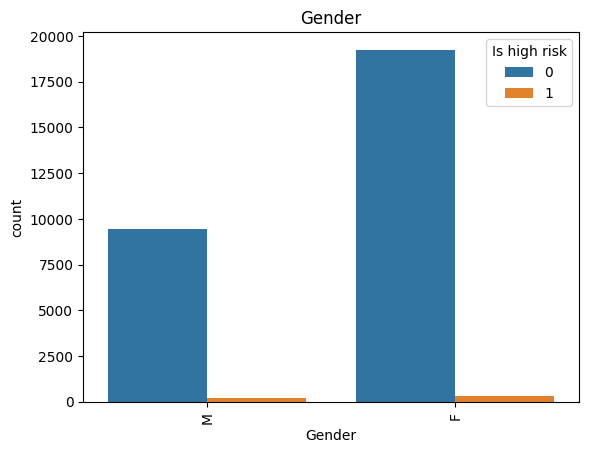

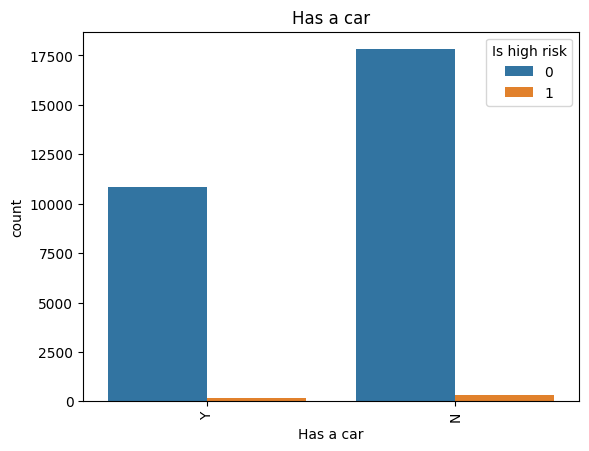

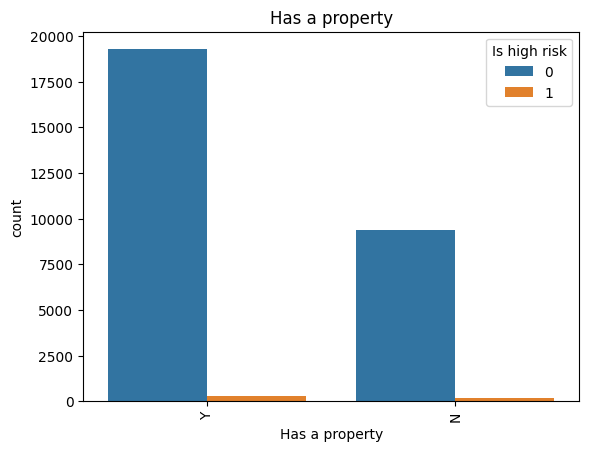

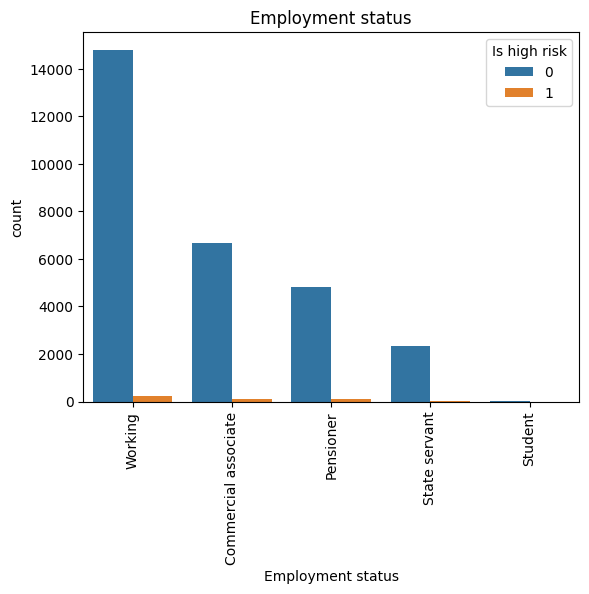

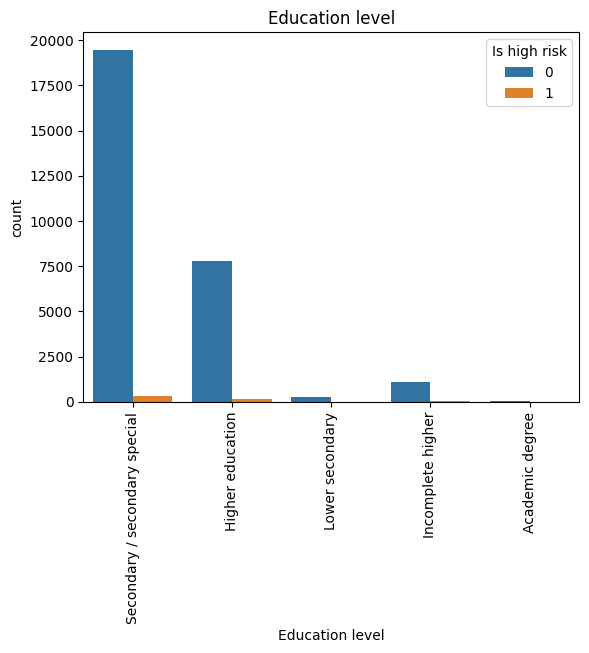

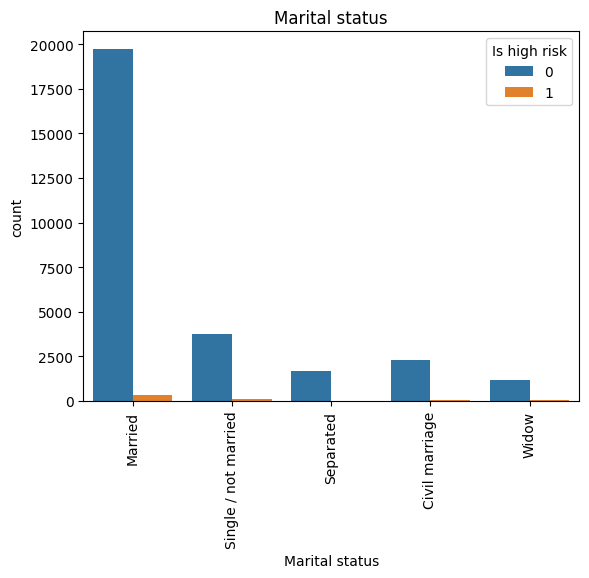

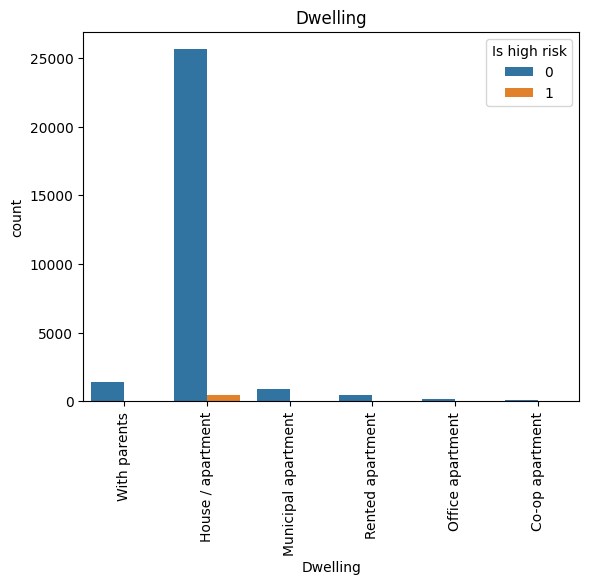

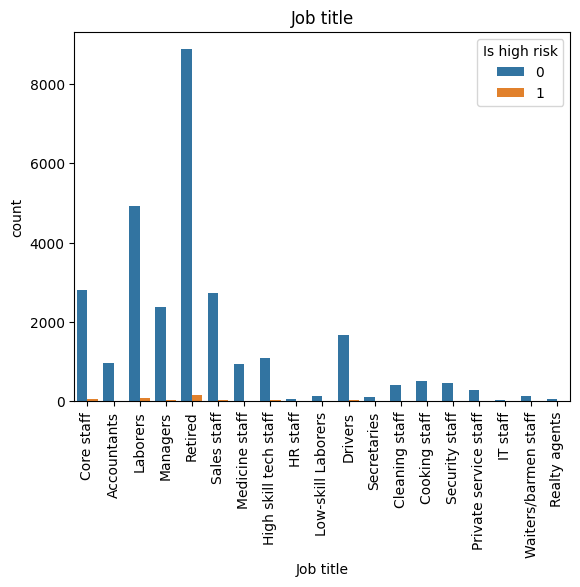

In [812]:
for col in cat_col:
  sns.countplot(x=df[col],hue=df['Is high risk'])
  plt.xticks(rotation=90)
  plt.title(col)
  plt.show()

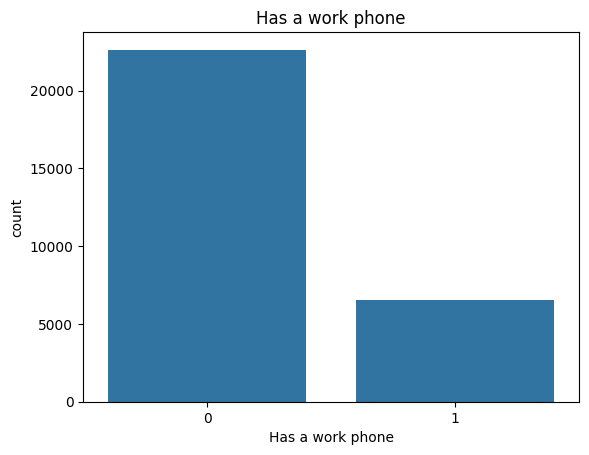

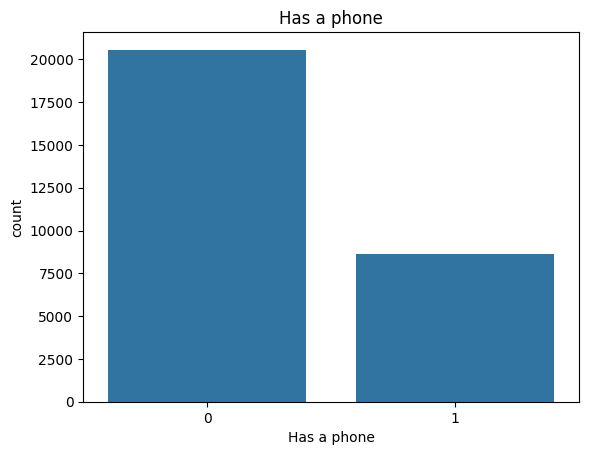

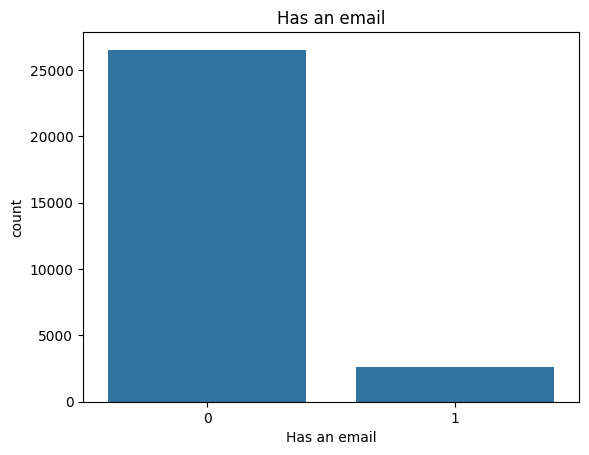

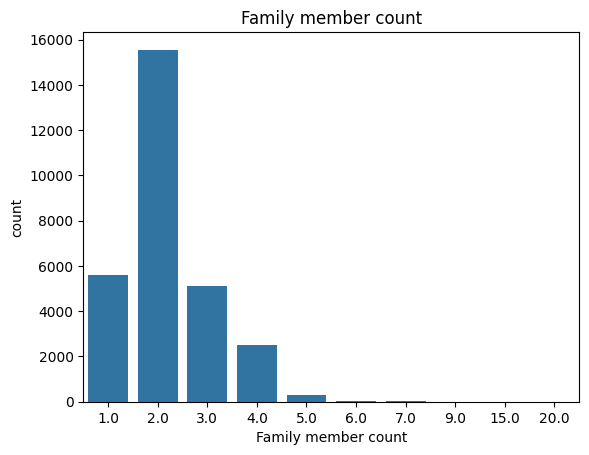

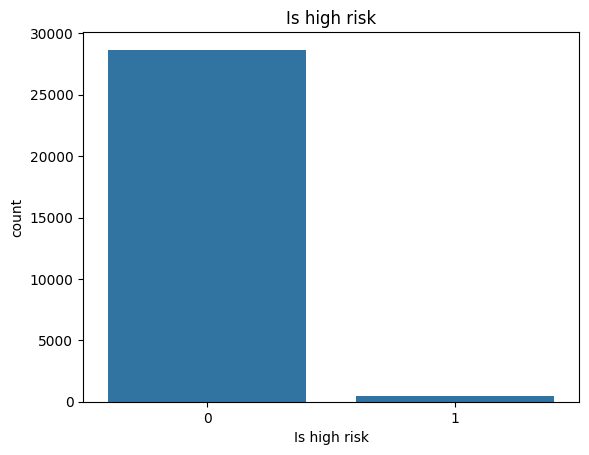

In [813]:
listtt=['Has a work phone', 'Has a phone', 'Has an email','Family member count', 'Is high risk']
for i in listtt:
  sns.countplot(x=df[i])
  plt.title(i)
  plt.show()

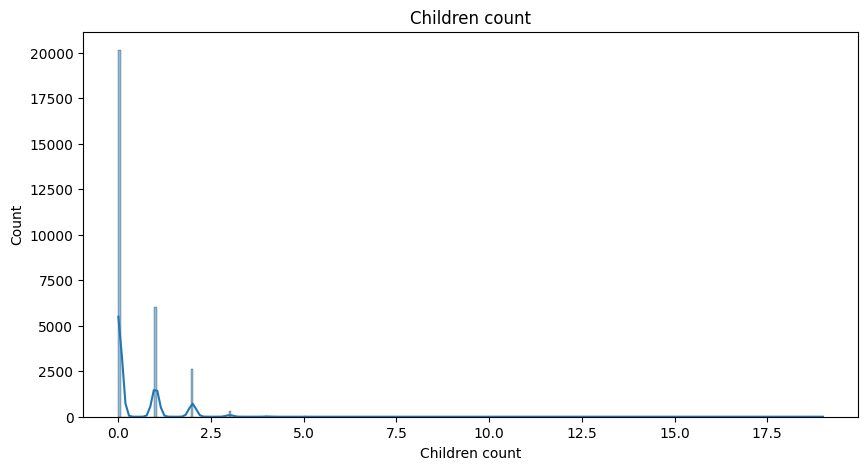

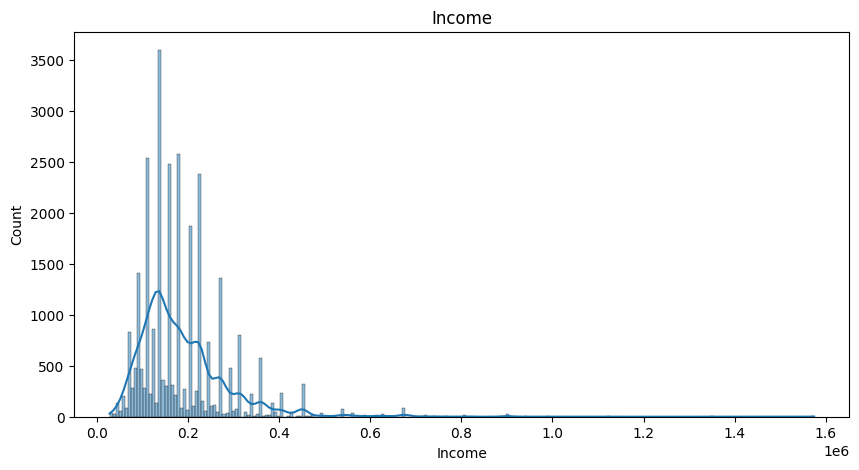

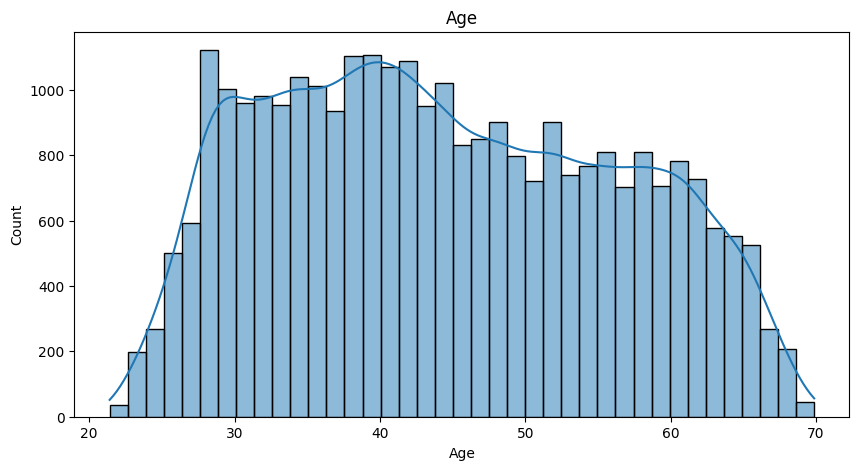

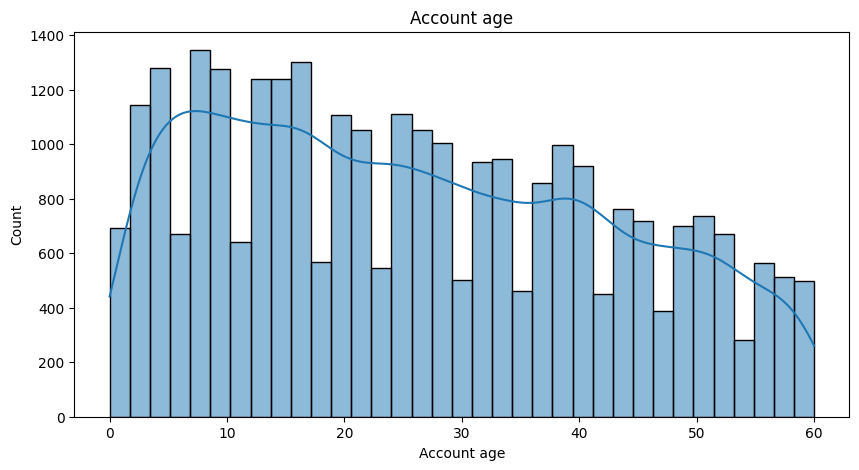

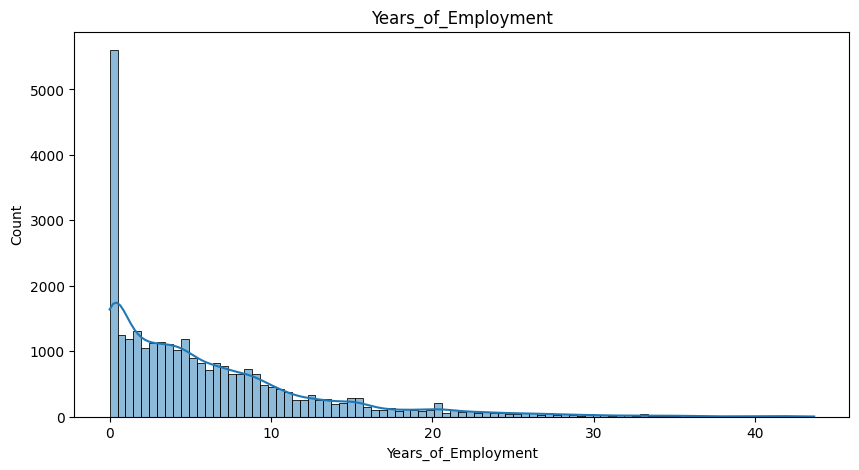

In [814]:
li=['Children count', 'Income', 'Age','Account age','Years_of_Employment']
for i in li:
  plt.figure(figsize=(10,5))
  sns.histplot(x=df[i],kde=True)
  plt.title(i)
  plt.show

In [815]:
df[df["Children count"]>5]

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk,Years_of_Employment
3743,F,N,N,7,157500.0,Working,Secondary / secondary special,Married,House / apartment,38.408333,1,1,0,Cleaning staff,9.0,26.0,0,4.580556
4445,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,49.316667,0,0,0,Drivers,15.0,7.0,0,4.691667
15261,F,N,Y,19,112500.0,Working,Secondary / secondary special,Single / not married,House / apartment,30.713889,1,1,0,Waiters/barmen staff,20.0,5.0,0,5.147222
16166,F,N,N,7,157500.0,Working,Secondary / secondary special,Married,House / apartment,38.408333,1,1,0,Cleaning staff,9.0,31.0,0,4.580556
25653,M,Y,Y,14,225000.0,Working,Secondary / secondary special,Separated,House / apartment,49.316667,0,0,0,Drivers,15.0,58.0,0,4.691667


In [816]:
df=df[df['Children count']<=10]

In [817]:
df["Income"].skew()

np.float64(2.7571016772903887)

In [818]:
df["Income"]=np.log1p(df["Income"])

In [819]:
num_col=df.select_dtypes(include=np.number).columns
cat_col=df.select_dtypes(include="object").columns

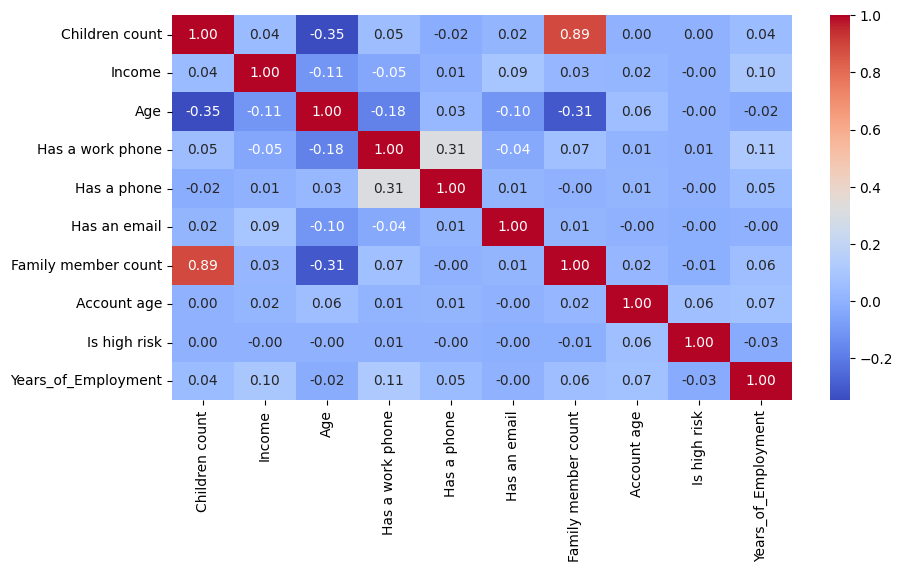

In [820]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True,fmt="0.02f",cmap="coolwarm")
plt.show()

In [821]:
df.drop(["Family member count"],axis=1,inplace=True)

In [822]:
df.head()

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Has a work phone,Has a phone,Has an email,Job title,Account age,Is high risk,Years_of_Employment
0,M,Y,Y,0,11.813037,Working,Secondary / secondary special,Married,With parents,45.197222,0,0,0,Core staff,17.0,0,8.641667
1,F,Y,N,1,11.813037,Commercial associate,Higher education,Single / not married,House / apartment,28.138889,0,0,0,Accountants,1.0,0,4.586111
2,F,N,Y,2,12.100718,Commercial associate,Secondary / secondary special,Married,House / apartment,35.613889,0,0,0,Laborers,38.0,0,15.713889
3,F,Y,Y,0,12.793862,Commercial associate,Higher education,Single / not married,House / apartment,58.136111,0,0,1,Managers,11.0,0,5.683333
4,F,N,N,0,12.506181,Working,Secondary / secondary special,Separated,House / apartment,45.019444,0,1,0,Retired,41.0,0,1.430556


# Feature Engineering

In [823]:
df['Employment_Age_Ratio'] = df['Years_of_Employment'] / df['Age']

In [824]:
df['Income_per_child_plus_1'] = df['Income'] / (df['Children count'] + 1)

In [825]:
df.head()

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Has a work phone,Has a phone,Has an email,Job title,Account age,Is high risk,Years_of_Employment,Employment_Age_Ratio,Income_per_child_plus_1
0,M,Y,Y,0,11.813037,Working,Secondary / secondary special,Married,With parents,45.197222,0,0,0,Core staff,17.0,0,8.641667,0.191199,11.813037
1,F,Y,N,1,11.813037,Commercial associate,Higher education,Single / not married,House / apartment,28.138889,0,0,0,Accountants,1.0,0,4.586111,0.162981,5.906519
2,F,N,Y,2,12.100718,Commercial associate,Secondary / secondary special,Married,House / apartment,35.613889,0,0,0,Laborers,38.0,0,15.713889,0.441229,4.033573
3,F,Y,Y,0,12.793862,Commercial associate,Higher education,Single / not married,House / apartment,58.136111,0,0,1,Managers,11.0,0,5.683333,0.097759,12.793862
4,F,N,N,0,12.506181,Working,Secondary / secondary special,Separated,House / apartment,45.019444,0,1,0,Retired,41.0,0,1.430556,0.031776,12.506181


# encoding

In [826]:
education_map = {
    'Academic degree': 4,
    'Higher education': 3,
    'Incomplete higher': 2,
    'Secondary / secondary special': 1,
    'Lower secondary': 0
}
df['Education level'] = df['Education level'].map(education_map)

In [827]:
df["Gender"]=df["Gender"].map({"M":1,"F":0})
df["Has a car"]=df["Has a car"].map({"Y":1,"N":0})
df["Has a property"]=df["Has a property"].map({"Y":1,"N":0})

In [828]:
l=["Employment status","Marital status","Dwelling","Job title"]
df=pd.get_dummies(df,columns=l,drop_first=True)

In [829]:
df.head()

,Gender,Has a car,Has a property,Children count,Income,Education level,Age,Has a work phone,Has a phone,Has an email,...,Job title_Low-skill Laborers,Job title_Managers,Job title_Medicine staff,Job title_Private service staff,Job title_Realty agents,Job title_Retired,Job title_Sales staff,Job title_Secretaries,Job title_Security staff,Job title_Waiters/barmen staff
0,1,1,1,0,11.813037,1,45.197222,0,0,0,...,False,False,False,False,False,False,False,False,False,False
1,0,1,0,1,11.813037,3,28.138889,0,0,0,...,False,False,False,False,False,False,False,False,False,False
2,0,0,1,2,12.100718,1,35.613889,0,0,0,...,False,False,False,False,False,False,False,False,False,False
3,0,1,1,0,12.793862,3,58.136111,0,0,1,...,False,True,False,False,False,False,False,False,False,False
4,0,0,0,0,12.506181,1,45.019444,0,1,0,...,False,False,False,False,False,True,False,False,False,False


# spliting

In [830]:
X=df.drop("Is high risk",axis=1)
y=df["Is high risk"]

In [831]:
X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

## Scalling

In [832]:
sc=StandardScaler()
X_train_sc=sc.fit_transform(X_train)
X_valid_sc=sc.transform(X_valid)

Smote (to solve unbalanced)

In [833]:
# from imblearn.over_sampling import SMOTE
# sm = SMOTE(random_state=42)
# X_train_res, y_train_res = sm.fit_resample(X_train_sc, y_train)

Model1

In [834]:
# model1 = RandomForestClassifier(n_estimators=50, max_depth=50)
# model1.fit(X_train_res, y_train_res)

# param = {
#     "n_estimators": [10, 20, 50, 100, 200,500],
#     "max_depth": [3, 5, 7, 9, 11,20,50]
# }

# grid = GridSearchCV(model1, param, cv=5, scoring='f1')

# grid.fit(X_train_res, y_train_res)

# print("Best Params:", grid.best_params_)
# print("Best Score (F1):", grid.best_score_)

In [835]:
# model1.score(X_train_res, y_train_res)

In [836]:
# model1.score(X_valid_sc, y_valid)

In [837]:
# y_pred_rf = model1.predict(X_valid_sc)

# print(classification_report(y_valid, y_pred_rf))


In [838]:
# cm = confusion_matrix(y_valid, y_pred_rf)
# plt.figure(figsize=(6,4))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
# plt.xlabel('Predicted')
# plt.ylabel('Actual')
# plt.show()

## model2

In [839]:
import xgboost as xgb

In [840]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()
print(f'Negative to Positive ratio: {ratio:.2f}')

Negative to Positive ratio: 57.47


In [841]:
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.2,
    scale_pos_weight=ratio,
    random_state=42
)
xgb_model.fit(X_train_sc, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.2, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [842]:
xgb_model.score(X_train_sc, y_train)

0.876548501864632

In [843]:
xgb_model.score(X_valid_sc, y_valid)

0.8666209497685582

In [844]:
# y_pred_xgb = xgb_model.predict(X_valid_sc)

In [845]:
y_probs = xgb_model.predict_proba(X_valid_sc)[:, 1]

y_pred_final = (y_probs > 0.4).astype(int)

In [846]:
print(classification_report(y_valid, y_pred_final))

              precision    recall  f1-score   support

           0       0.99      0.77      0.87      5733
           1       0.05      0.69      0.09       100

    accuracy                           0.77      5833
   macro avg       0.52      0.73      0.48      5833
weighted avg       0.98      0.77      0.85      5833



Text(50.722222222222214, 0.5, 'actual')

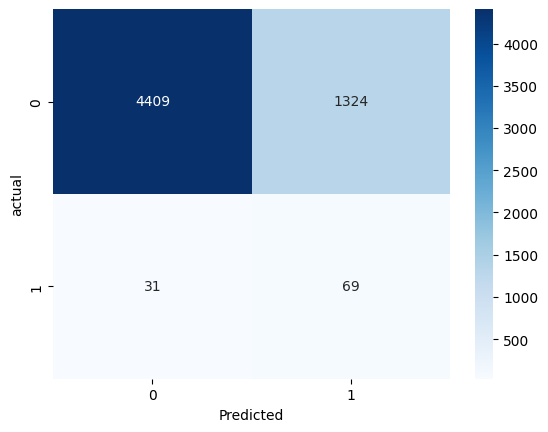

In [847]:
cm = confusion_matrix(y_valid, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('actual')

model3

In [848]:
# import lightgbm as lgb
# from xgboost import XGBClassifier

In [849]:
# base_model=[
#      ('rf',RandomForestClassifier(n_estimators=50, max_depth=50)),
#      ('xgb', XGBClassifier(n_estimators=100, max_depth=3, scale_pos_weight=ratio, random_state=42)),
#      ('lgbm', lgb.LGBMClassifier(n_estimators=100, max_depth=3, is_unbalance=True, random_state=42))
# ]
# final_xgb = XGBClassifier(scale_pos_weight=ratio, max_depth=3)

In [850]:
# stacking_model=StackingClassifier(estimators=base_model,final_estimator=final_xgb,cv=5)

In [851]:
# stacking_model.fit(X_train_sc,y_train)

In [852]:
# stacking_model.score(X_train_sc,y_train)

In [853]:
# stacking_model.score(X_valid_sc,y_valid)

In [854]:
# y_pred_stack = stacking_model.predict(X_valid_sc)
# print(classification_report(y_valid, y_pred_stack))

In [855]:
# y_probs_stack = stacking_model.predict_proba(X_valid_sc)[:, 1]

# y_pred_custom = (y_probs_stack > 0.4).astype(int)

# from sklearn.metrics import classification_report
# print("Stacking with Threshold 0.05:")
# print(classification_report(y_valid, y_pred_custom))

# Test

In [856]:
test=pd.read_csv("/content/test_data.csv")
test.head()

,ID,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Employment length,Has a mobile phone,Has a work phone,Has a phone,Has an email,Job title,Family member count,Account age,Is high risk
0,5091261,F,N,Y,0,202500.0,State servant,Secondary / secondary special,Separated,House / apartment,-16834,-1692,1,0,0,0,Medicine staff,1.0,-6.0,0
1,5096963,M,Y,N,0,675000.0,Commercial associate,Higher education,Married,House / apartment,-18126,-948,1,0,1,0,Managers,2.0,-16.0,0
2,5087880,F,N,N,0,234000.0,State servant,Higher education,Civil marriage,House / apartment,-21967,-5215,1,0,0,1,Core staff,2.0,-52.0,0
3,5021949,F,Y,Y,0,445500.0,Commercial associate,Higher education,Married,House / apartment,-12477,-456,1,0,0,0,Managers,2.0,-54.0,0
4,5105705,F,Y,N,0,225000.0,Working,Secondary / secondary special,Married,Municipal apartment,-12155,-667,1,0,0,0,Laborers,2.0,-48.0,0


In [857]:
test_id=test["ID"]
test.drop(["ID"],axis=1,inplace=True)

In [858]:
test["Job title"]=test["Job title"].fillna("Retired")

In [859]:
test["Age"]=test["Age"]/-360
test['Years_of_Employment']=test['Employment length'].apply(lambda x:0 if x>0 else x/-360)
test['Account age']=test['Account age'].apply(lambda x:0 if x==0 else x*-1)
test.drop(["Employment length"],axis=1,inplace=True)

In [860]:
test.drop(["Has a mobile phone"],axis=1,inplace=True)

In [861]:
test["Income"]=np.log1p(test["Income"])

In [862]:
test.drop(["Family member count"],axis=1,inplace=True)

In [863]:
test['Employment_Age_Ratio'] = test['Years_of_Employment'] / test['Age']
test['Income_per_child_plus_1'] = test['Income'] / (test['Children count'] + 1)

In [864]:
test.head()

,Gender,Has a car,Has a property,Children count,Income,Employment status,Education level,Marital status,Dwelling,Age,Has a work phone,Has a phone,Has an email,Job title,Account age,Is high risk,Years_of_Employment,Employment_Age_Ratio,Income_per_child_plus_1
0,F,N,Y,0,12.218500,State servant,Secondary / secondary special,Separated,House / apartment,46.761111,0,0,0,Medicine staff,6.0,0,4.700000,0.100511,12.218500
1,M,Y,N,0,13.422469,Commercial associate,Higher education,Married,House / apartment,50.350000,0,1,0,Managers,16.0,0,2.633333,0.052301,13.422469
2,F,N,N,0,12.363081,State servant,Higher education,Civil marriage,House / apartment,61.019444,0,0,1,Core staff,52.0,0,14.486111,0.237402,12.363081
3,F,Y,Y,0,13.006955,Commercial associate,Higher education,Married,House / apartment,34.658333,0,0,0,Managers,54.0,0,1.266667,0.036547,13.006955
4,F,Y,N,0,12.323860,Working,Secondary / secondary special,Married,Municipal apartment,33.763889,0,0,0,Laborers,48.0,0,1.852778,0.054875,12.323860


In [865]:
education_map = {
    'Academic degree': 4,
    'Higher education': 3,
    'Incomplete higher': 2,
    'Secondary / secondary special': 1,
    'Lower secondary': 0
}
test['Education level'] = test['Education level'].map(education_map)
test["Gender"]=test["Gender"].map({"M":1,"F":0})
test["Has a car"]=test["Has a car"].map({"Y":1,"N":0})
test["Has a property"]=test["Has a property"].map({"Y":1,"N":0})
l=["Employment status","Marital status","Dwelling","Job title"]
test=pd.get_dummies(test,columns=l,drop_first=True)

In [866]:
X_test_final = test.drop(columns=['Is high risk'])

In [867]:
X_test_scaled = sc.transform(X_test_final)

In [868]:
test_probs = xgb_model.predict_proba(X_test_scaled)[:, 1]
test_preds = (test_probs > 0.4).astype(int)

In [869]:
import joblib

joblib.dump(xgb_model, 'credit_risk_model.pkl')

joblib.dump(sc,'scaler.pkl')

['scaler.pkl']

In [870]:
submission = pd.DataFrame({
    'ID': test_id,
    'Is high risk': test_preds
})
submission.to_csv('submission_final.csv', index=False)